In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd "/content/drive/MyDrive/Master's Thesis/TM Project/"

/content/drive/MyDrive/Master's Thesis/TM Project


In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
# !pip install scikit-optimize

In [ ]:
# from skopt import gp_minimize
# from skopt import space

In [ ]:
import devices
import models
import samplers
import trainers
import utils

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

from scipy.io import loadmat

In [ ]:
# parameters
lambd = 1

# wave number and normalized spacing
k_0 = 2 * np.pi / lambd

# device 2
#spacing
dx = (0.0968/1.55) * k_0
dy =  (0.05/1.55) * k_0

# simulation lengths

core_length_x = ((3/1.55) * lambd) * k_0 # W
core_length_y = ((0.1/1.55) * lambd) * k_0 # H

substrate_length_x = ((3.05/1.55) * lambd) * k_0 # Xs
substrate_length_y = ((5.025/1.55) * lambd) * k_0 # Ys

rib_length = ((0.9/1.55) * lambd) * k_0 # D

cladding_length_y = ((0.525/1.55) * lambd) * k_0 # Yc

# refractive indices
n_core = 3.44
n_substrate = 3.36
n_cladding = 1

In [ ]:
study = 'scalar'

In [ ]:
memory_type = torch.device('cuda')
dtype = torch.float32
torch.manual_seed(42)
num_modes = 1

In [ ]:
reference_device = devices.RibWaveguide(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study)

In [ ]:
xy = samplers.uniform_grid_2d(reference_device, dx, dy, dtype, memory_type)
xy = xy.cpu()

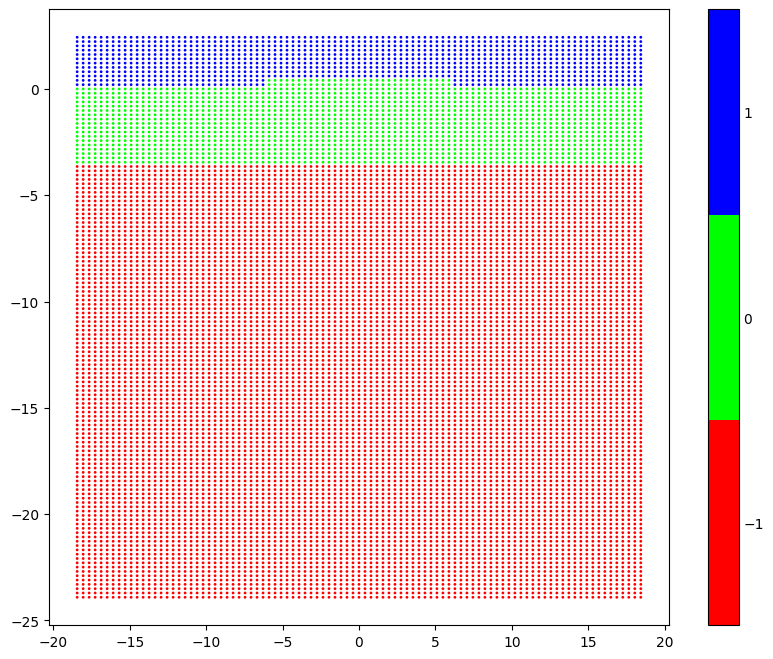

In [ ]:
plt.figure(figsize=(10, 8))

from_list = matplotlib.colors.LinearSegmentedColormap.from_list
cm = from_list(None, [(1, 0, 0), (0, 1, 0), (0, 0, 1)], 3)
plt.scatter(xy[:, 0], xy[:, 1], s=1, c=reference_device.regions(xy, format='torch'), cmap=cm);
plt.clim(-1.5, 1.5)
cb = plt.colorbar(ticks=[-1, 0, 1])
cb.ax.tick_params(length=0)

In [ ]:
boudndary_pts, boundary_vals = reference_device.get_boundaries(xy.detach().clone(), dx, dy, dtype,  memory_type)

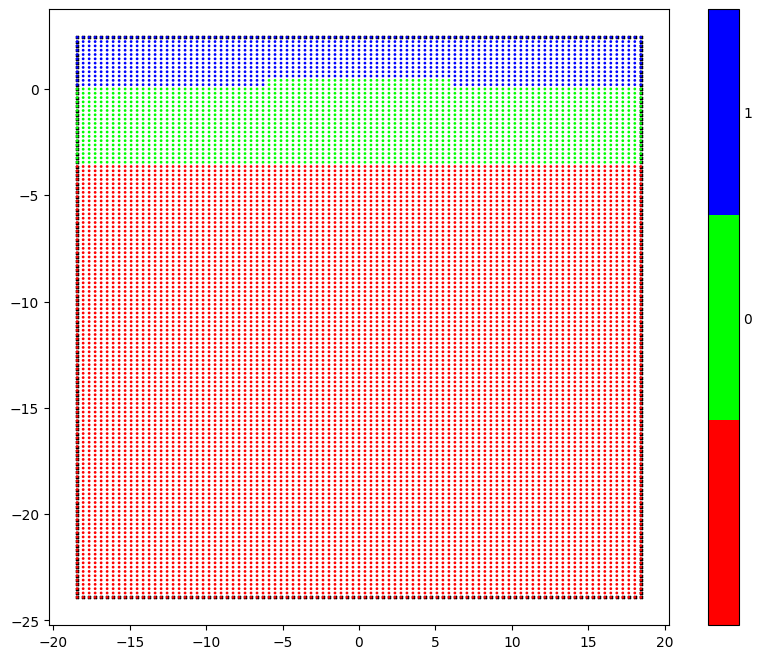

In [ ]:
plt.figure(figsize=(10, 8))

from_list = matplotlib.colors.LinearSegmentedColormap.from_list
cm = from_list(None, [(1, 0, 0), (0, 1, 0), (0, 0, 1)], 3)
plt.scatter(boudndary_pts[:, 0], boudndary_pts[:, 1], marker='x', s=4, c='black');
plt.scatter(xy[:, 0], xy[:, 1], s=1, c=reference_device.regions(xy, format='torch'), cmap=cm);
plt.clim(-1.5, 1.5)
cb = plt.colorbar(ticks=[0, 1])
cb.ax.tick_params(length=0)

In [ ]:
discontinuities = reference_device.get_discontinuities(xy.detach().clone(), dx, dy)

<ipython-input-16-8c52820d3a78>:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(boudndary_pts[:, 0], boudndary_pts[:, 1], marker='x', s=4, c='black', cmap=cm);
<ipython-input-16-8c52820d3a78>:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(discontinuity[:, 0].detach(), discontinuity[:, 1].detach(), s=1/2, marker='x', c='orange', cmap=cm);


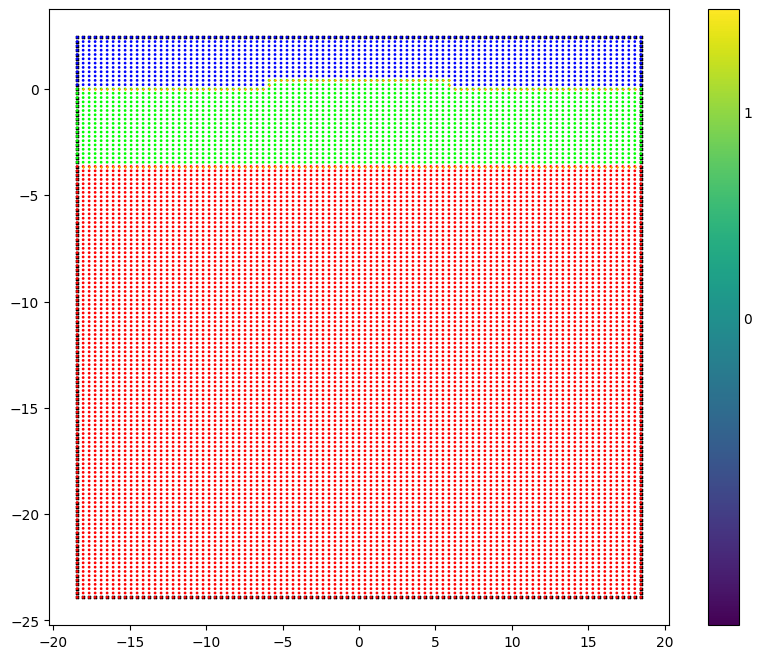

In [ ]:
plt.figure(figsize=(10, 8))

from_list = matplotlib.colors.LinearSegmentedColormap.from_list
cm = from_list(None, [(1, 0, 0), (0, 1, 0), (0, 0, 1)], 3)
plt.scatter(boudndary_pts[:, 0], boudndary_pts[:, 1], marker='x', s=4, c='black', cmap=cm);

plt.scatter(xy[:, 0], xy[:, 1], s=1, c=reference_device.regions(xy, format='torch'), cmap=cm);

for discontinuity in discontinuities:
  plt.scatter(discontinuity[:, 0].detach(), discontinuity[:, 1].detach(), s=1/2, marker='x', c='orange', cmap=cm);

# len_rib = guide.lengths_y[1]
# len_rib = ((guide.lengths_y[1])//dy)*dy

# plt.axhline(y=-len_rib, color='black', linestyle='dashed')
plt.clim(-1.5, 1.5)
cb = plt.colorbar(ticks=[0, 1])
cb.ax.tick_params(length=0)

In [ ]:
study = 'scalar'

In [ ]:
memory_type = torch.device('cuda')
dtype = torch.float32
torch.manual_seed(42)
num_modes = 1

In [ ]:
# base_model = models.discontinuity_capturing_network(2, 256, num_modes, 1, 'RBF')
base_model = models.discontinuity_capturing_network(2, 512, num_modes, 1, 'DRBF')
optimizer = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
# optimizer = torch.optim.LBFGS(base_model.parameters(),
#                               lr=float(5e-1),
#                               max_iter=5000,
#                               max_eval=5000,
#                               history_size=300,
#                               line_search_fn="strong_wolfe",
#                               tolerance_change=10.0 * np.finfo(float).eps)
# scheduler = torch.optim.lr_scheduler.MultiStepLR(optimzer, milestones=[1000, 2000, 3000], gamma=0.2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[3000, 4000, 5000], gamma=0.2)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

number of trainable parameters 3073


In [ ]:
device = devices.RibWaveguideWithPINNs(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, base_model, True)

In [ ]:
train_agent = trainers.Trainer2D(dtype, device, memory_type, samplers.uniform_grid_2d, optimizer, scheduler, dx=dx, dy=dy, num_samples=None, n_lower=None, n_upper=None)

num samples 12445


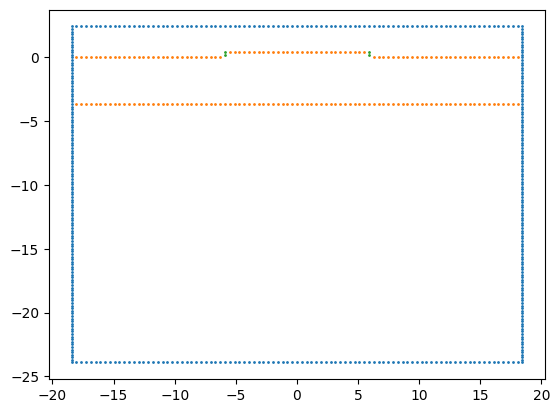

iteration 1 loss1 is 0.21606, loss2 is 0.79924, loss3 is 13.59643, loss4 is 0.0, loss5 is 0.08345, loss6 is 0.43736
3.171766996383667


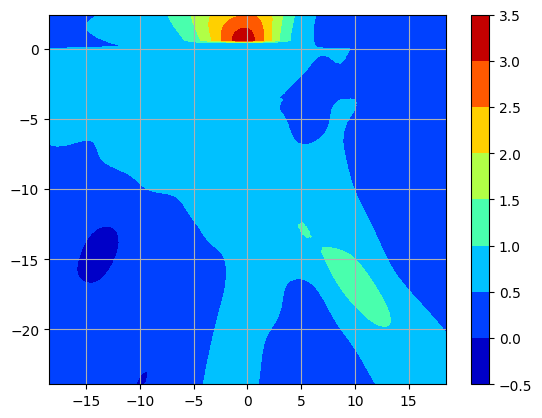

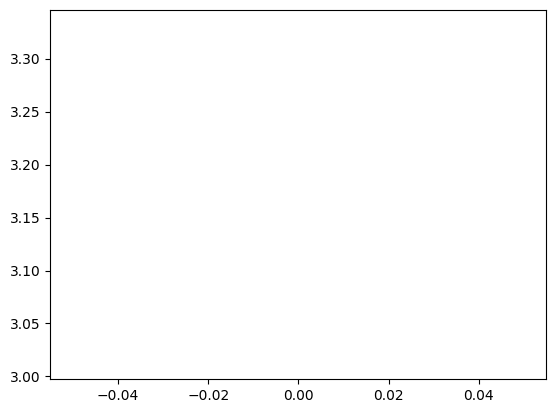

iteration 1001 loss1 is 0.03283, loss2 is 0.00902, loss3 is 0.53343, loss4 is 0.0, loss5 is 0.00854, loss6 is 0.07985
3.3952183723449707


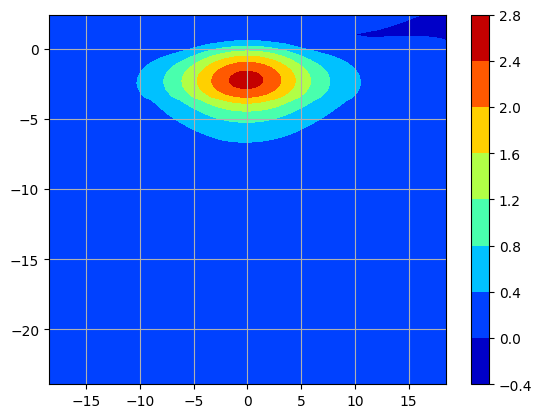

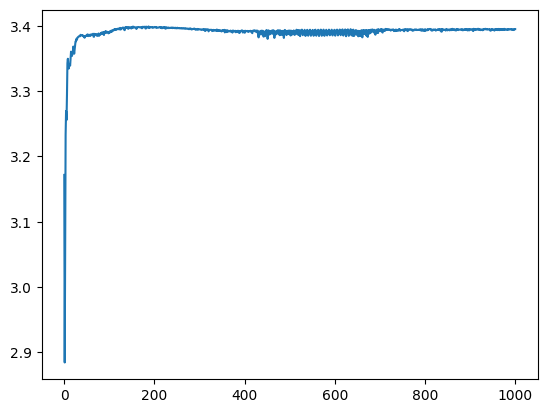

iteration 2001 loss1 is 0.02772, loss2 is 0.0007, loss3 is 0.53562, loss4 is 0.0, loss5 is 0.00774, loss6 is 0.05184
3.394912004470825


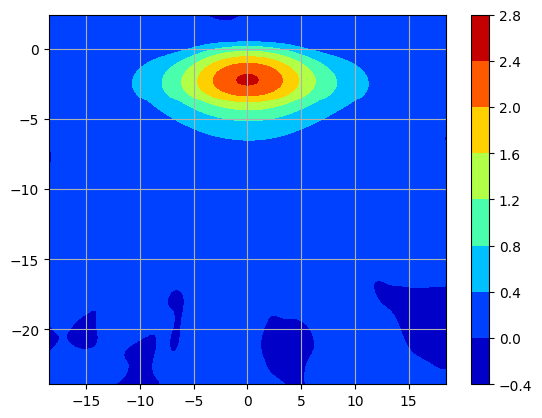

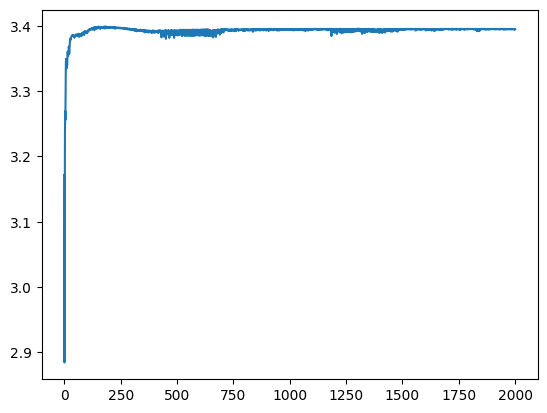

iteration 3001 loss1 is 0.02015, loss2 is 0.00182, loss3 is 0.53284, loss4 is 0.0, loss5 is 0.00518, loss6 is 0.02873
3.3953018188476562


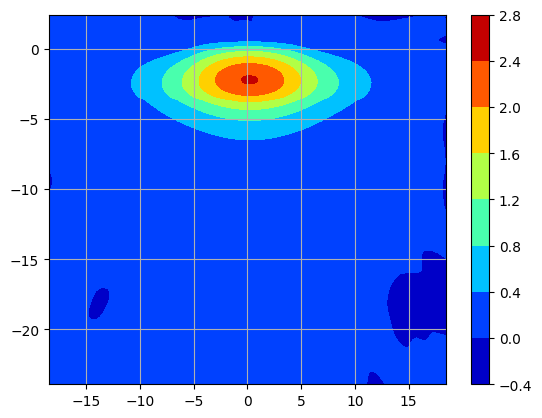

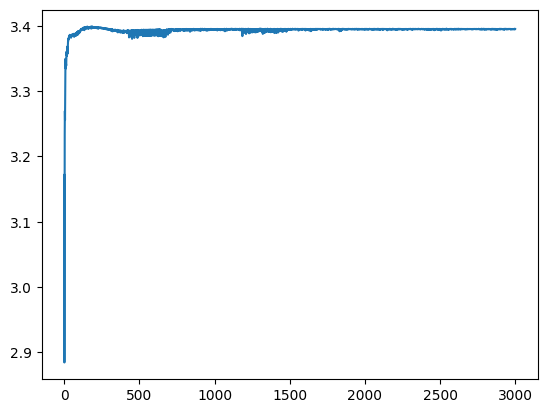

iteration 4001 loss1 is 0.0129, loss2 is 0.00123, loss3 is 0.53309, loss4 is 0.0, loss5 is 0.00205, loss6 is 0.02037
3.39526629447937


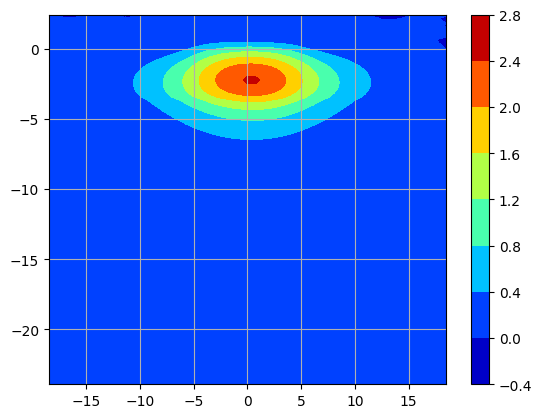

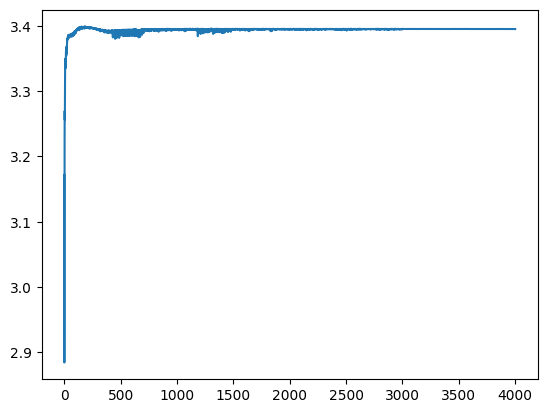

iteration 5001 loss1 is 0.01069, loss2 is 0.00157, loss3 is 0.53283, loss4 is 0.0, loss5 is 0.00093, loss6 is 0.01926
3.395303249359131


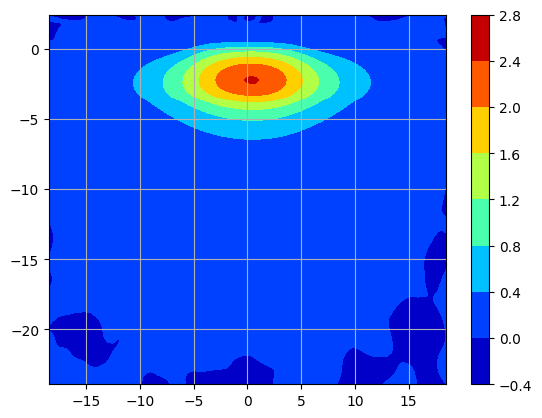

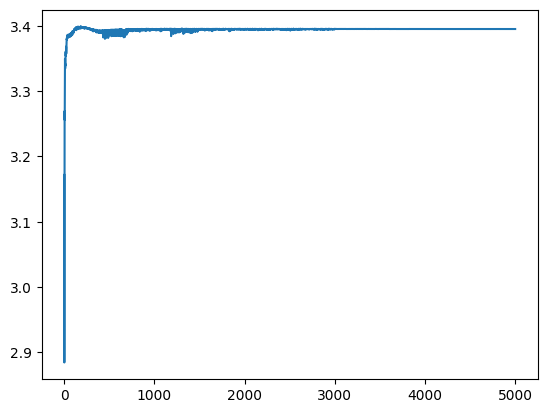

iteration 6001 loss1 is 0.01037, loss2 is 0.00146, loss3 is 0.53286, loss4 is 0.0, loss5 is 0.00077, loss6 is 0.0179
3.395298480987549


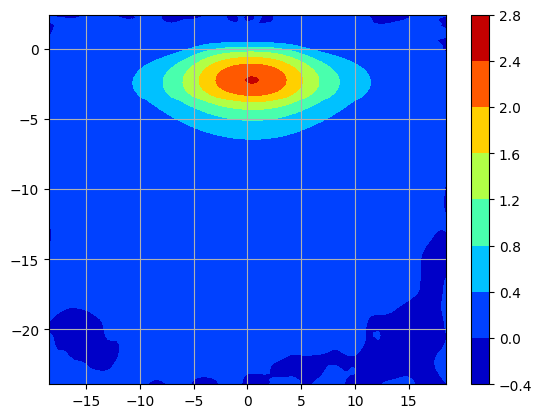

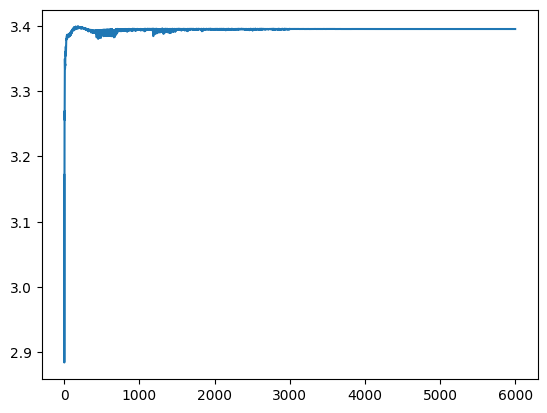

iteration 7001 loss1 is 0.0103, loss2 is 0.00142, loss3 is 0.53285, loss4 is 0.0, loss5 is 0.00079, loss6 is 0.01736
3.3953001499176025


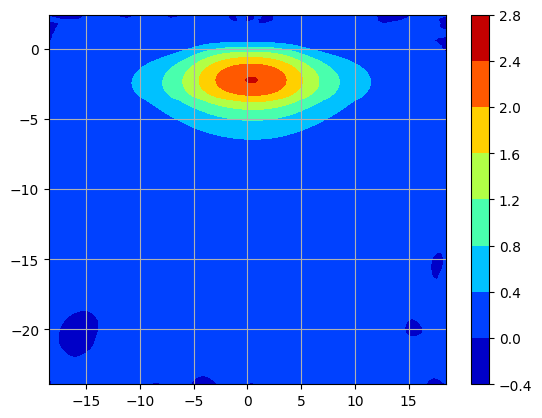

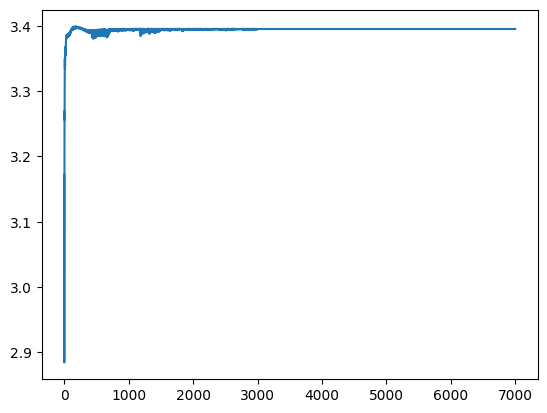

iteration 8001 loss1 is 0.01016, loss2 is 0.00127, loss3 is 0.53289, loss4 is 0.0, loss5 is 0.00079, loss6 is 0.01622
3.395294427871704


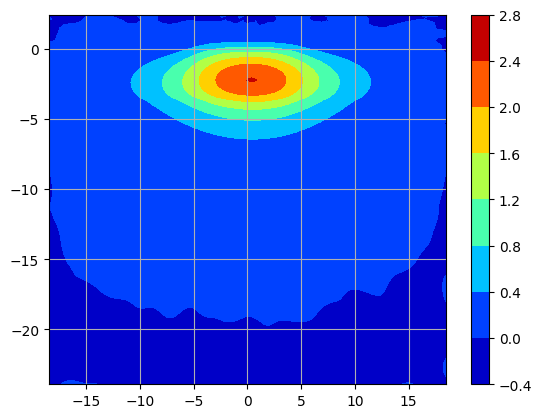

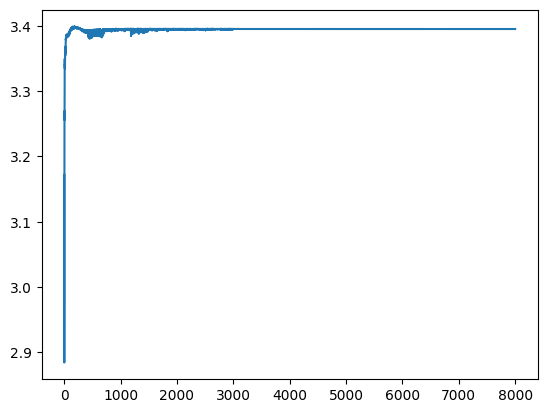

iteration 9001 loss1 is 0.00988, loss2 is 0.00131, loss3 is 0.53296, loss4 is 0.0, loss5 is 0.00071, loss6 is 0.01647
3.395285129547119


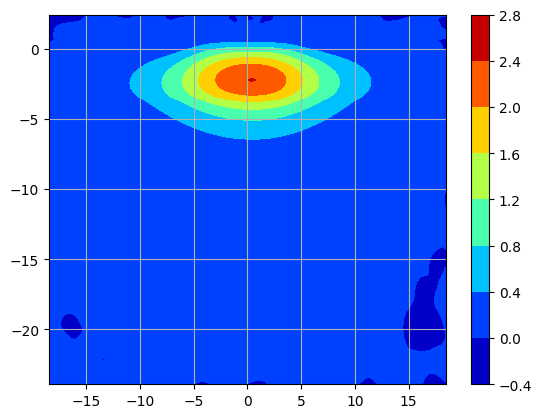

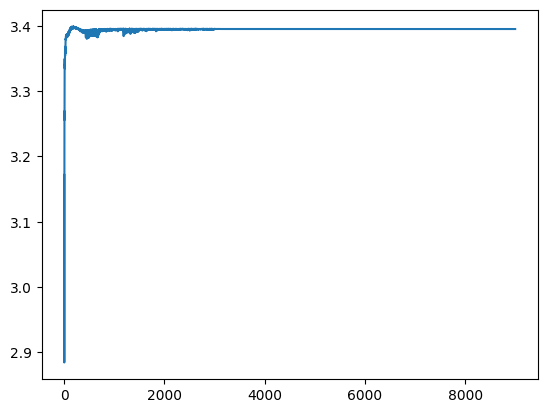

iteration 10001 loss1 is 0.00984, loss2 is 0.00119, loss3 is 0.53306, loss4 is 0.0, loss5 is 0.00075, loss6 is 0.01524
3.395270586013794


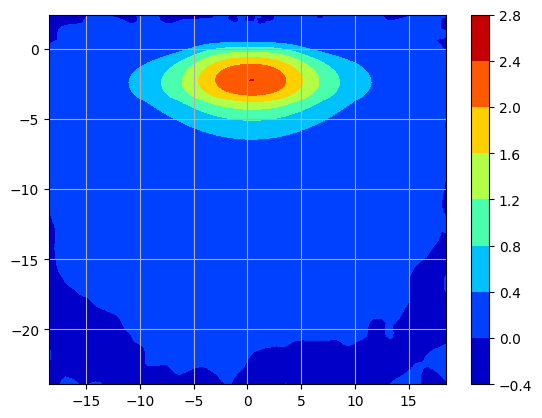

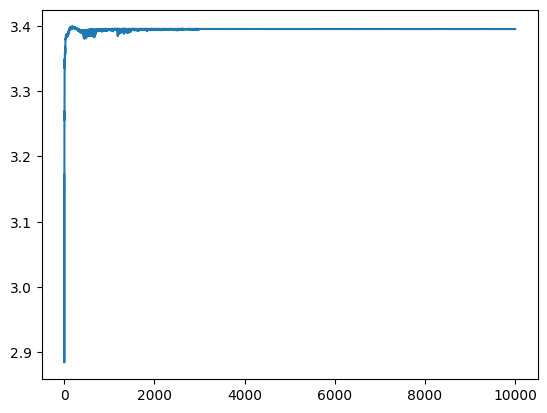

In [ ]:
# loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=[1, 1, 1, 1, 1, 1], verbose=1, sample_new=False)
loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=[1, 1/2, 1, 1, 1, 1], verbose=1, calc_error=False, plot_solution=True, sample_new=False)

In [ ]:
base_model.to('cpu')

Sequential(
  (0): Linear(in_features=3, out_features=512, bias=True)
  (1): RBF()
  (2): Linear(in_features=512, out_features=1, bias=True)
)

In [ ]:
yu = torch.arange(0, reference_device.upward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yu = yu[-1]
yb = torch.arange(0, reference_device.downward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yb = yb[-1]
xy = torch.cat((torch.flip(-yb, dims=(0,))[:-1], yu))

xy = torch.cat((torch.full_like(xy, 0), xy), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy, torch.square(reference_device.refractive_index(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()

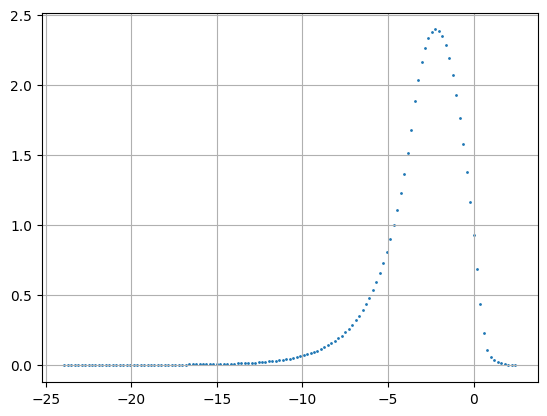

In [ ]:
plt.scatter(xy[:, 1].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [ ]:
xy = torch.arange(-device.total_length_x/2, device.total_length_x/2, step=dx/2, device=memory_type).reshape(-1, 1)
xy = torch.cat((xy, torch.full_like(xy, 0)), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy[:], torch.square(device.refractive_index(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()

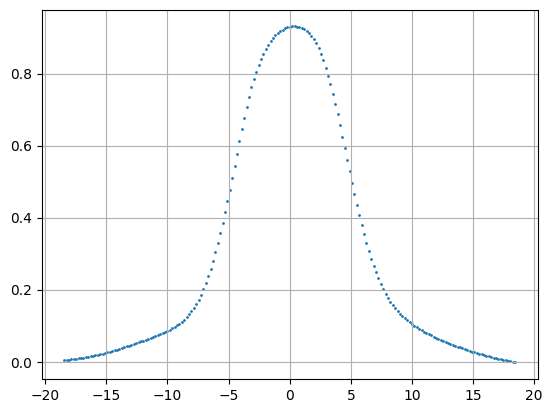

In [ ]:
plt.scatter(xy[:, 0].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [ ]:
study = 'TE'

In [ ]:
memory_type = torch.device('cuda')
dtype = torch.float32
torch.manual_seed(42)
num_modes = 1

In [ ]:
# base_model = models.discontinuity_capturing_network(2, 256, num_modes, 1, 'RBF')
base_model = models.discontinuity_capturing_network(2, 512, num_modes, 1, 'DRBF')
optimizer = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
# optimizer = torch.optim.LBFGS(base_model.parameters(),
#                               lr=float(5e-1),
#                               max_iter=5000,
#                               max_eval=5000,
#                               history_size=300,
#                               line_search_fn="strong_wolfe",
#                               tolerance_change=10.0 * np.finfo(float).eps)
# scheduler = torch.optim.lr_scheduler.MultiStepLR(optimzer, milestones=[1000, 2000, 3000], gamma=0.2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[3000, 4000, 5000], gamma=0.2)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

number of trainable parameters 3073


In [ ]:
device = devices.RibWaveguideWithPINNs(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, base_model, True)

In [ ]:
train_agent = trainers.Trainer2D(dtype, device, memory_type, samplers.uniform_grid_2d, optimizer, scheduler, dx=dx, dy=dy, num_samples=None, n_lower=None, n_upper=None)

num samples 12445


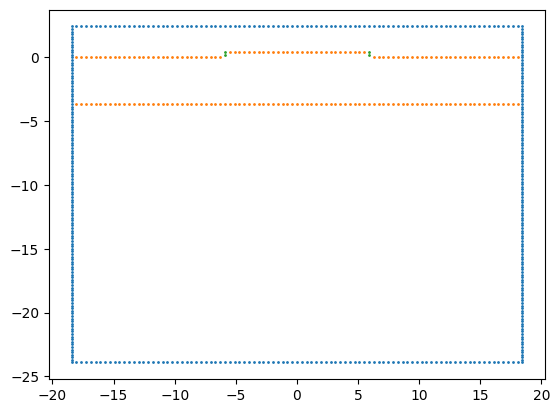

iteration 1 loss1 is 0.21606, loss2 is 0.79924, loss3 is 13.59643, loss4 is 0.0, loss5 is 0.08345, loss6 is 1.31835
3.171766996383667


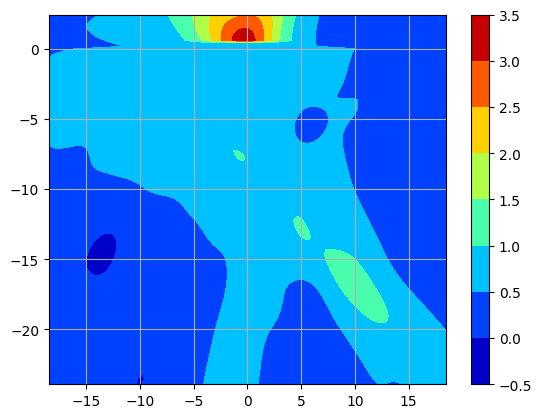

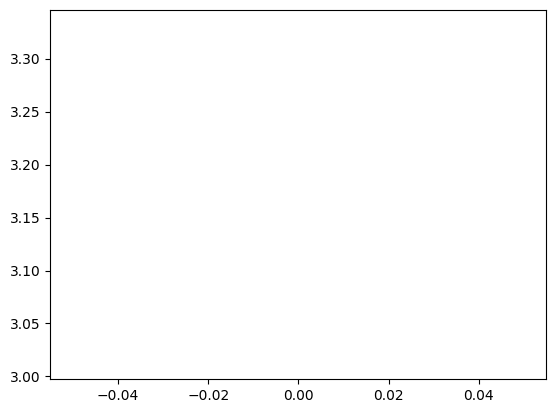

iteration 1001 loss1 is 0.03938, loss2 is 0.0401, loss3 is 0.54621, loss4 is 0.0, loss5 is 0.00453, loss6 is 0.24619
3.393460750579834


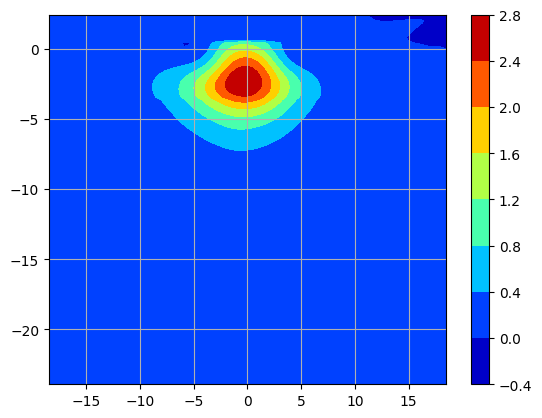

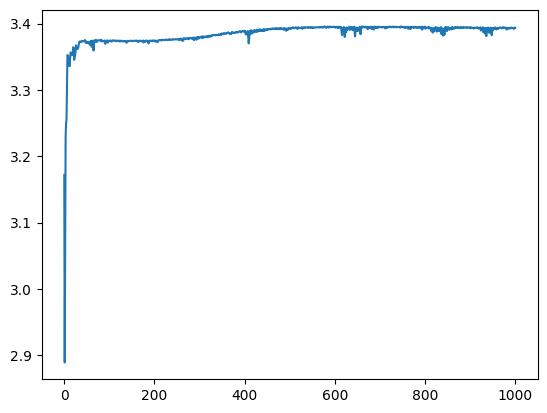

iteration 2001 loss1 is 0.0379, loss2 is 0.01596, loss3 is 0.5738, loss4 is 0.0, loss5 is 0.00833, loss6 is 0.17169
3.3899309635162354


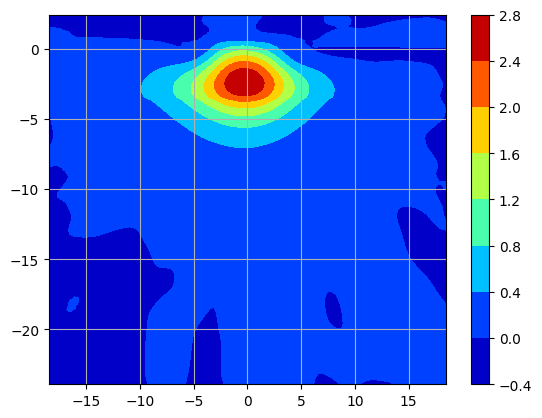

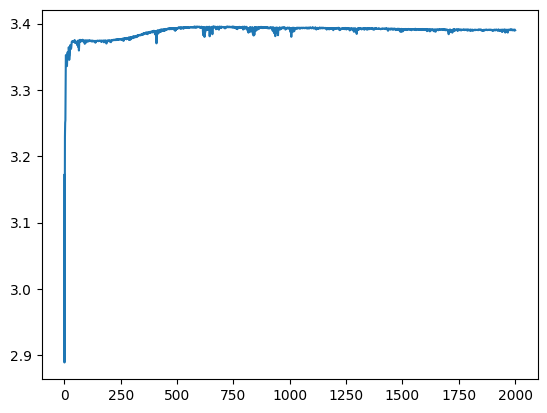

iteration 3001 loss1 is 0.025, loss2 is 0.01434, loss3 is 0.56492, loss4 is 0.0, loss5 is 0.00374, loss6 is 0.12083
3.3910303115844727


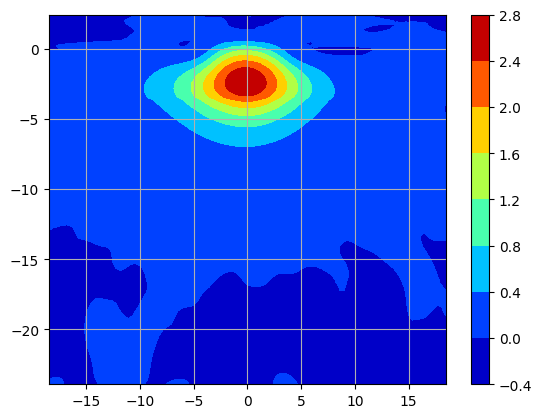

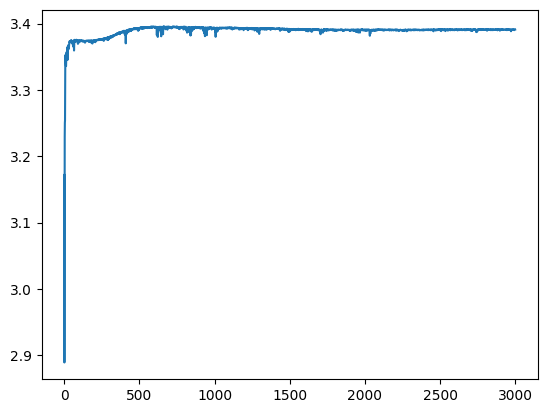

iteration 4001 loss1 is 0.02098, loss2 is 0.00608, loss3 is 0.56358, loss4 is 0.0, loss5 is 0.0019, loss6 is 0.04928
3.3911986351013184


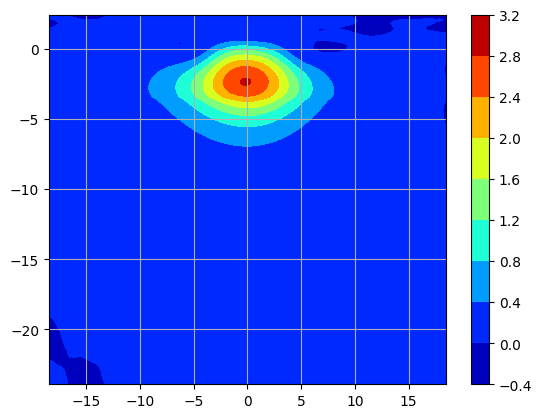

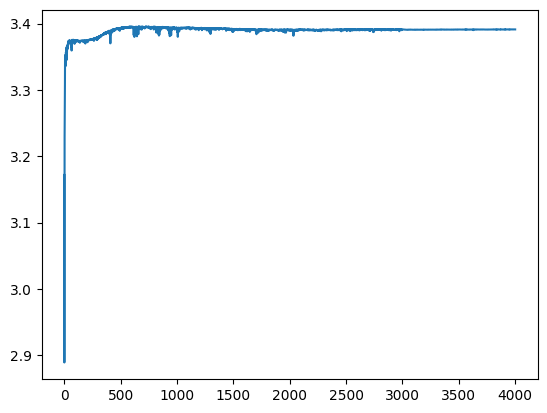

iteration 5001 loss1 is 0.01903, loss2 is 0.00572, loss3 is 0.56383, loss4 is 0.0, loss5 is 0.0009, loss6 is 0.03029
3.391167640686035


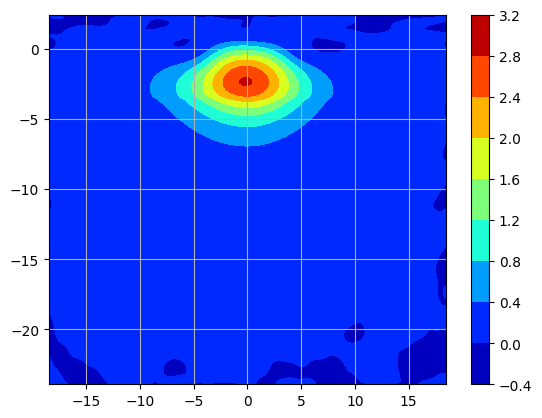

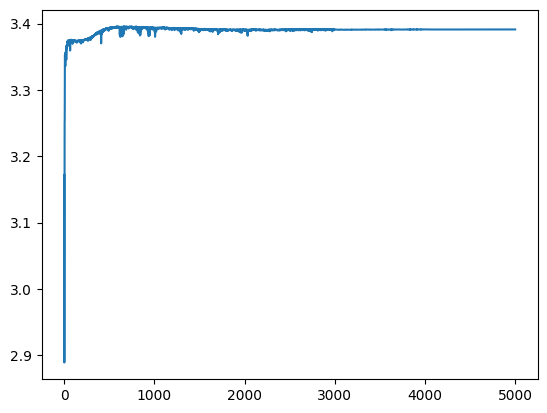

iteration 6001 loss1 is 0.01877, loss2 is 0.00517, loss3 is 0.56333, loss4 is 0.0, loss5 is 0.00091, loss6 is 0.03423
3.391230821609497


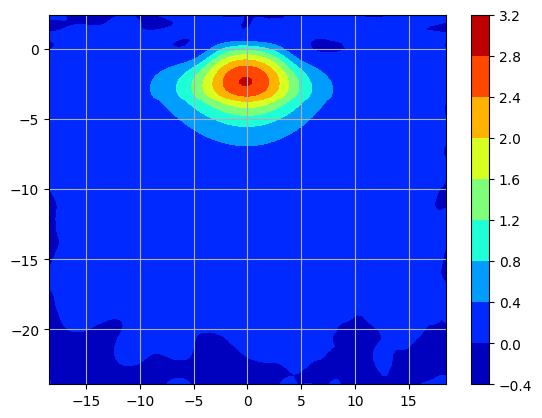

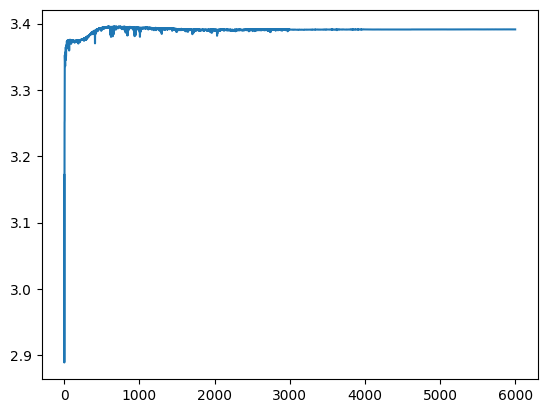

iteration 7001 loss1 is 0.01826, loss2 is 0.00481, loss3 is 0.56215, loss4 is 0.0, loss5 is 0.00101, loss6 is 0.02331
3.391380548477173


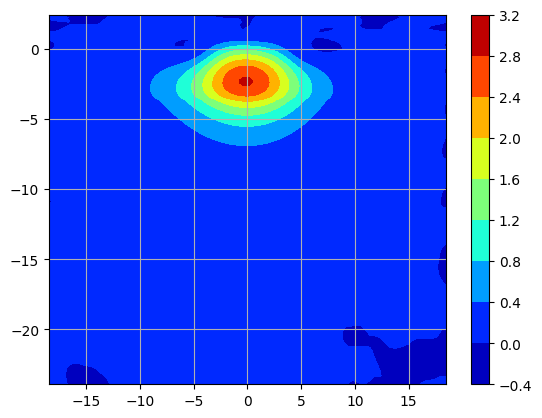

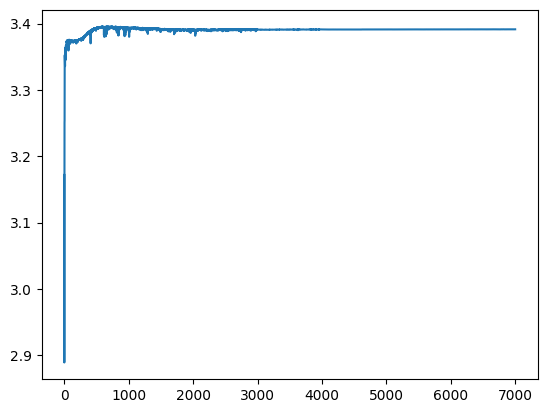

iteration 8001 loss1 is 0.01795, loss2 is 0.00456, loss3 is 0.56178, loss4 is 0.0, loss5 is 0.00096, loss6 is 0.02285
3.3914263248443604


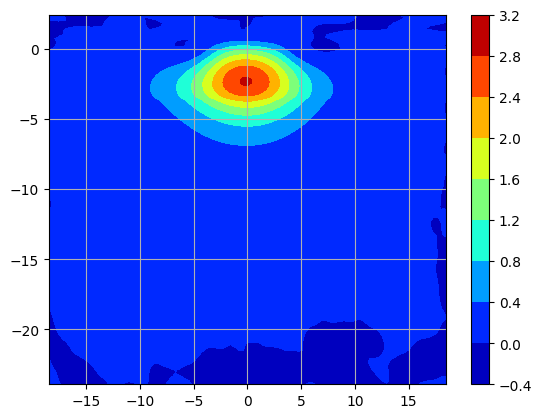

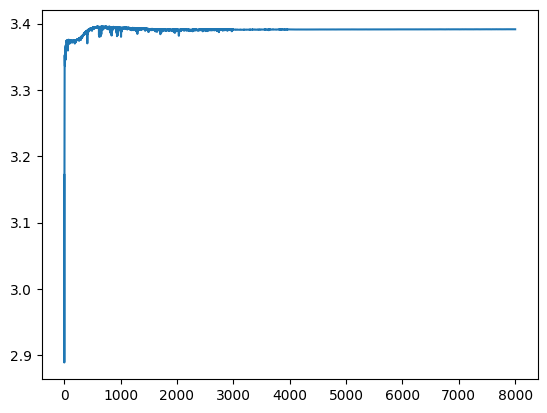

iteration 9001 loss1 is 0.0175, loss2 is 0.0045, loss3 is 0.56094, loss4 is 0.0, loss5 is 0.00102, loss6 is 0.02319
3.3915343284606934


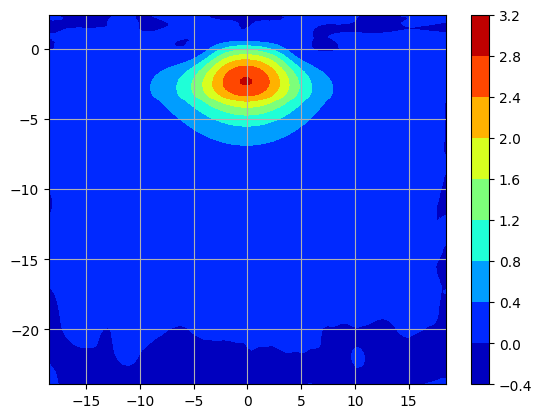

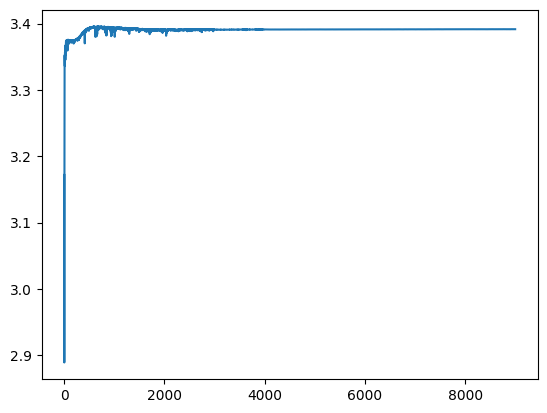

iteration 10001 loss1 is 0.01726, loss2 is 0.00454, loss3 is 0.56019, loss4 is 0.0, loss5 is 0.00115, loss6 is 0.02193
3.391629457473755


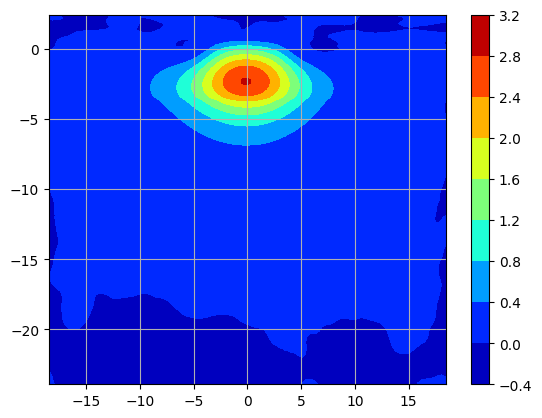

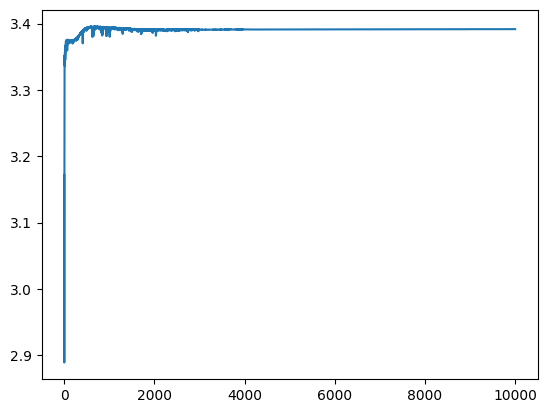

In [ ]:
# loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=[1, 1, 1, 1, 1, 1], verbose=1, sample_new=False)
loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=[1, 1/2, 1, 1, 1, 1], verbose=1, calc_error=False, plot_solution=True, sample_new=False)

In [ ]:
base_model.to('cpu')

Sequential(
  (0): Linear(in_features=3, out_features=512, bias=True)
  (1): RBF()
  (2): Linear(in_features=512, out_features=1, bias=True)
)

In [ ]:
yu = torch.arange(0, reference_device.upward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yu = yu[-1]
yb = torch.arange(0, reference_device.downward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yb = yb[-1]
xy = torch.cat((torch.flip(-yb, dims=(0,))[:-1], yu))

xy = torch.cat((torch.full_like(xy, 0), xy), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy, torch.square(reference_device.refractive_index(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()

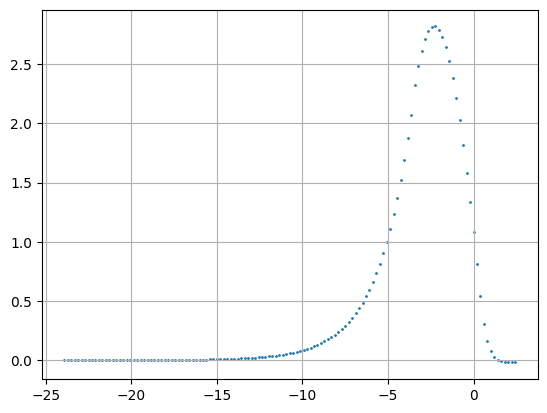

In [ ]:
plt.scatter(xy[:, 1].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [ ]:
xy = torch.arange(-device.total_length_x/2, device.total_length_x/2, step=dx/2, device=memory_type).reshape(-1, 1)
xy = torch.cat((xy, torch.full_like(xy, 0)), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy[:], torch.square(device.refractive_index(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()

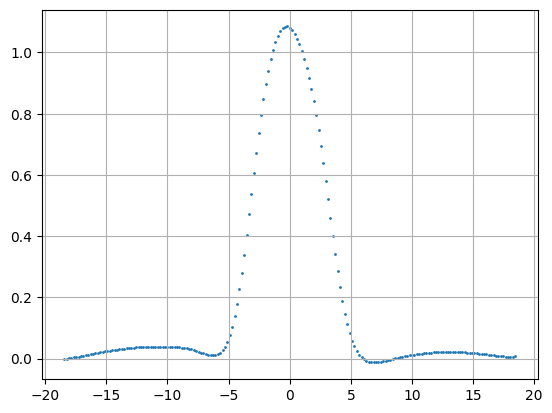

In [ ]:
plt.scatter(xy[:, 0].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [ ]:
study = 'TM'

In [ ]:
memory_type = torch.device('cuda')
dtype = torch.float32
torch.manual_seed(42)
num_modes = 1

In [ ]:
# base_model = models.discontinuity_capturing_network(2, 256, num_modes, 1, 'RBF')
base_model = models.discontinuity_capturing_network(2, 512, num_modes, 1, 'DRBF')
optimizer = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
# optimizer = torch.optim.LBFGS(base_model.parameters(),
#                               lr=float(5e-1),
#                               max_iter=5000,
#                               max_eval=5000,
#                               history_size=300,
#                               line_search_fn="strong_wolfe",
#                               tolerance_change=10.0 * np.finfo(float).eps)
# scheduler = torch.optim.lr_scheduler.MultiStepLR(optimzer, milestones=[1000, 2000, 3000], gamma=0.2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[3000, 4000, 5000], gamma=0.2)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

number of trainable parameters 3073


In [ ]:
device = devices.RibWaveguideWithPINNs(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, base_model, True)

In [ ]:
train_agent = trainers.Trainer2D(dtype, device, memory_type, samplers.uniform_grid_2d, optimizer, scheduler, dx=dx, dy=dy, num_samples=None, n_lower=None, n_upper=None)

num samples 12445


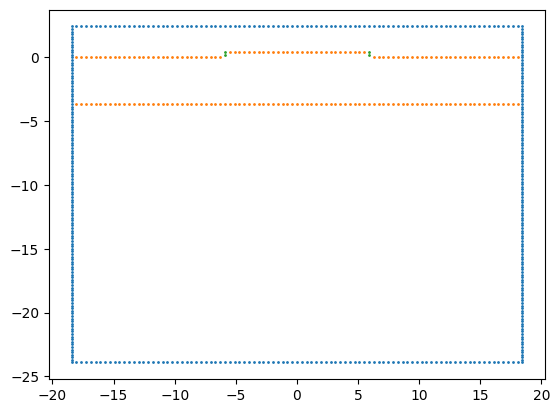

iteration 1 loss1 is 0.21606, loss2 is 0.79924, loss3 is 13.59643, loss4 is 0.0, loss5 is 0.08345, loss6 is 0.83274
3.171766996383667


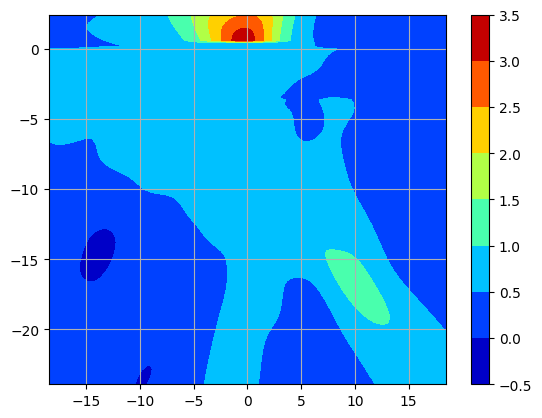

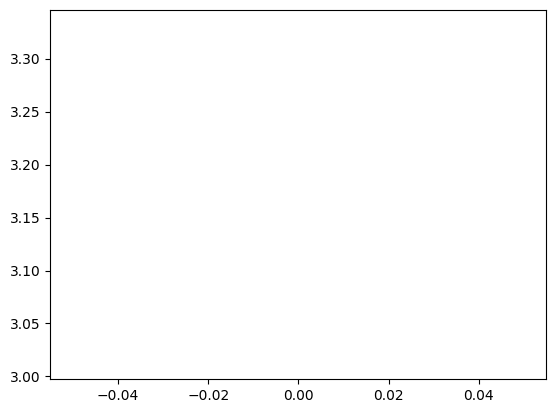

iteration 1001 loss1 is 0.03929, loss2 is 0.01331, loss3 is 0.92669, loss4 is 0.0, loss5 is 0.00793, loss6 is 0.10272
3.3632009029388428


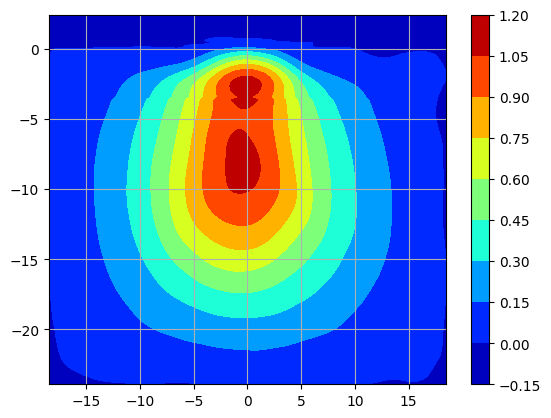

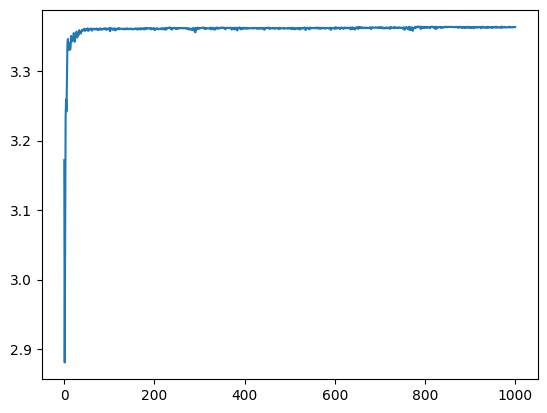

iteration 2001 loss1 is 0.04804, loss2 is 0.01846, loss3 is 0.71347, loss4 is 0.0, loss5 is 0.00779, loss6 is 0.08853
3.376216173171997


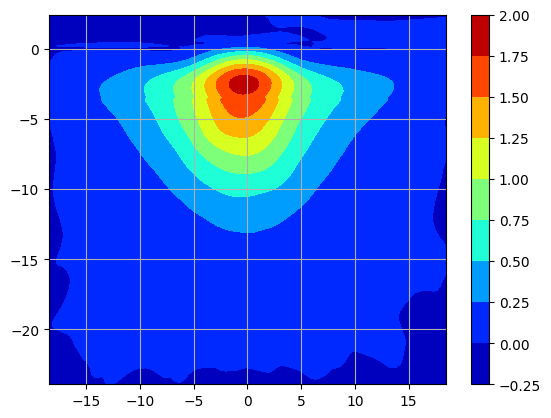

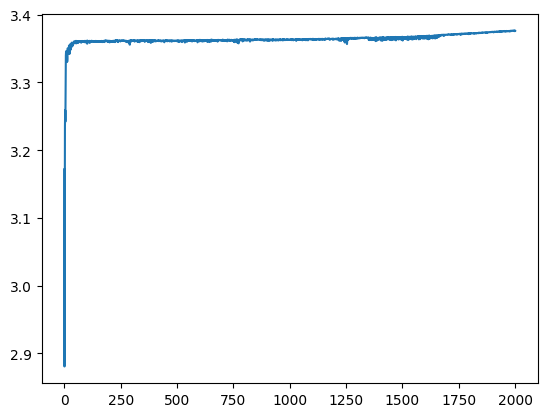

iteration 3001 loss1 is 0.03662, loss2 is 0.02677, loss3 is 0.61534, loss4 is 0.0, loss5 is 0.00575, loss6 is 0.13177
3.3852081298828125


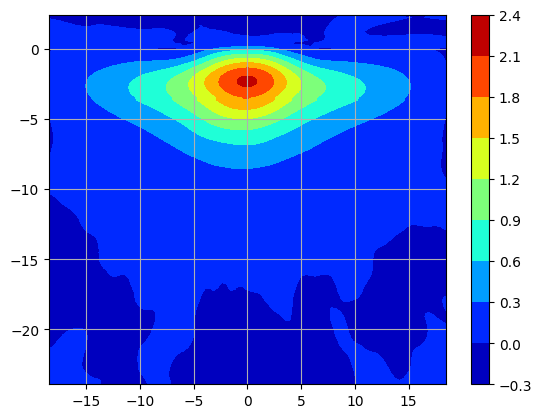

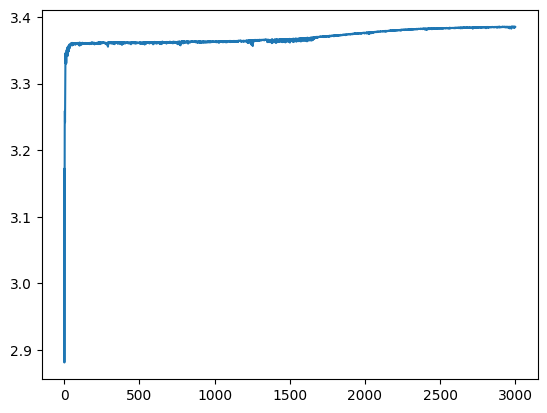

iteration 4001 loss1 is 0.02764, loss2 is 0.01542, loss3 is 0.60153, loss4 is 0.0, loss5 is 0.00282, loss6 is 0.03506
3.386707067489624


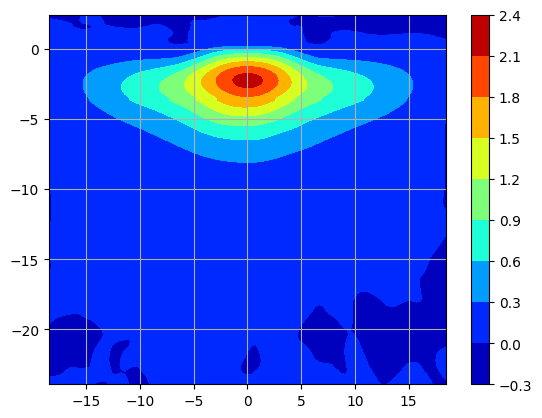

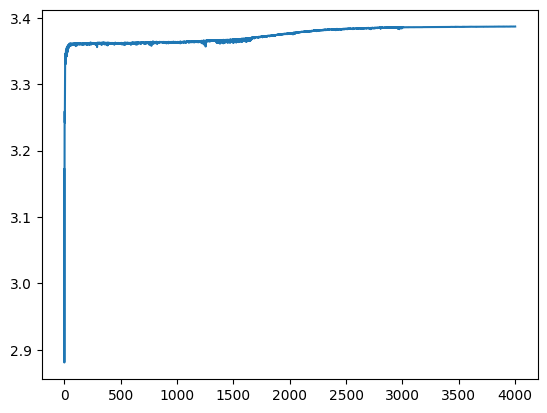

iteration 5001 loss1 is 0.02563, loss2 is 0.01488, loss3 is 0.59988, loss4 is 0.0, loss5 is 0.00197, loss6 is 0.02307
3.386890411376953


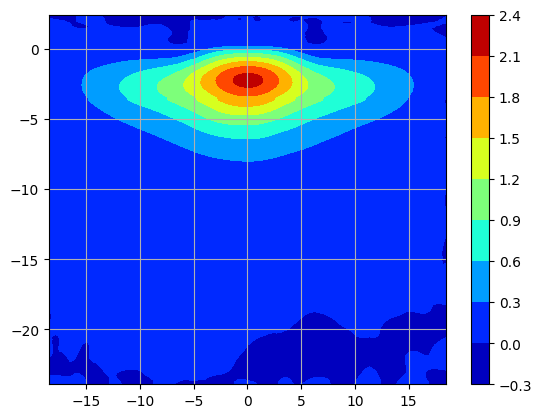

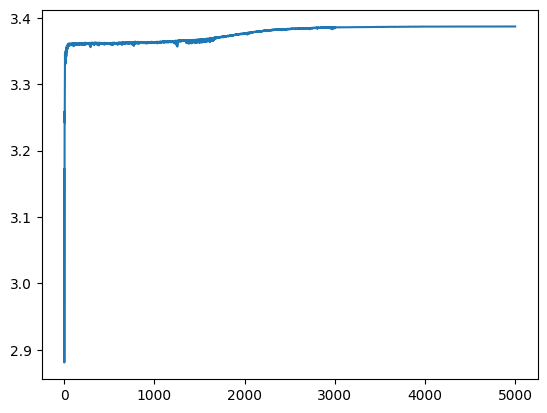

iteration 6001 loss1 is 0.02499, loss2 is 0.01435, loss3 is 0.5985, loss4 is 0.0, loss5 is 0.00192, loss6 is 0.02545
3.387044906616211


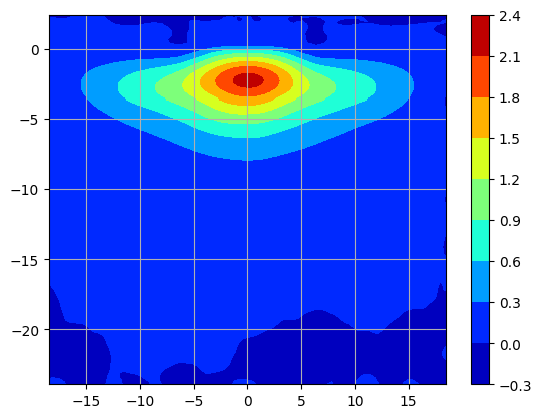

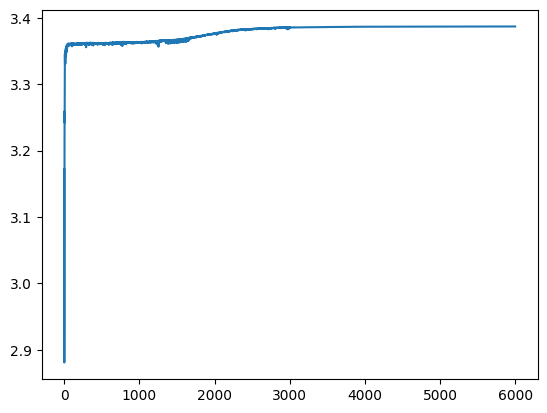

iteration 7001 loss1 is 0.02435, loss2 is 0.01368, loss3 is 0.59727, loss4 is 0.0, loss5 is 0.00172, loss6 is 0.02335
3.3871827125549316


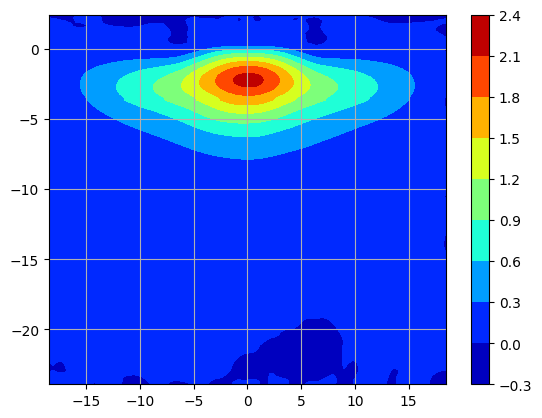

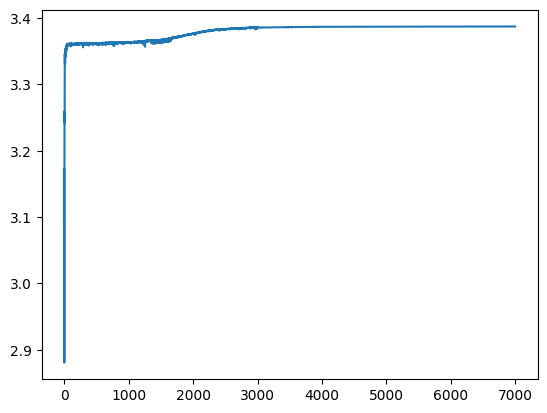

iteration 8001 loss1 is 0.02373, loss2 is 0.01318, loss3 is 0.59623, loss4 is 0.0, loss5 is 0.00159, loss6 is 0.02307
3.3873002529144287


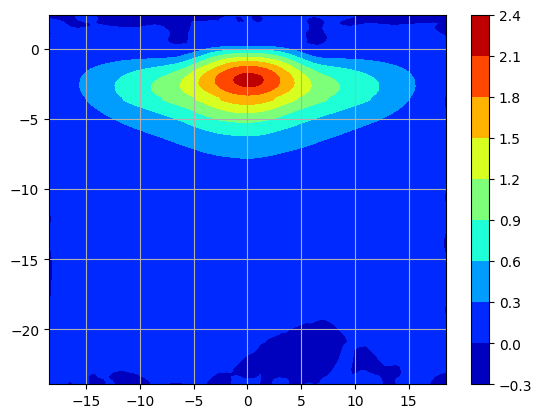

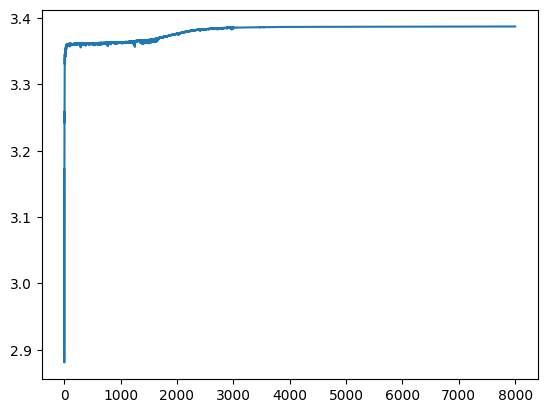

iteration 9001 loss1 is 0.02314, loss2 is 0.01225, loss3 is 0.5954, loss4 is 0.0, loss5 is 0.00147, loss6 is 0.02185
3.3873934745788574


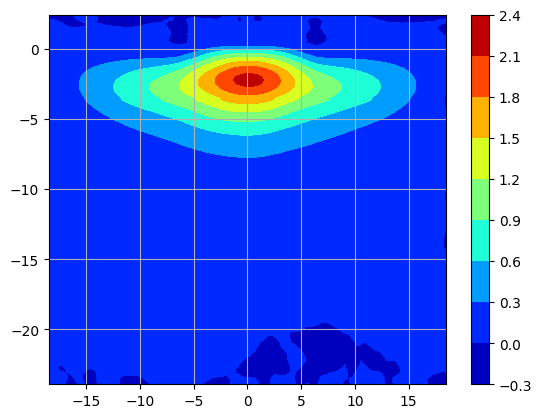

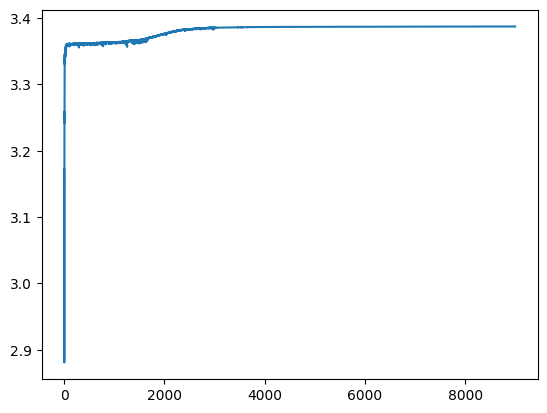

iteration 10001 loss1 is 0.0227, loss2 is 0.01141, loss3 is 0.5944, loss4 is 0.0, loss5 is 0.00141, loss6 is 0.02643
3.3875067234039307


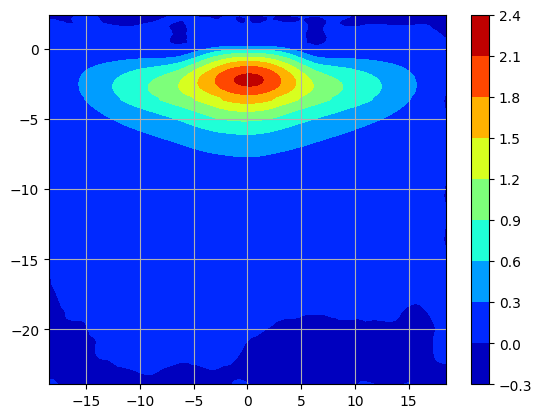

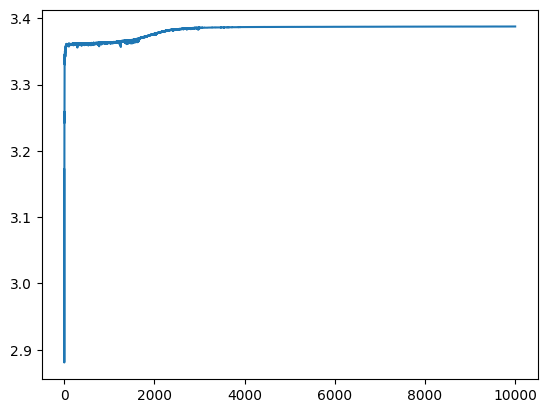

In [ ]:
# loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=[1, 1, 1, 1, 1, 1], verbose=1, sample_new=False)
loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=[1, 1/2, 1, 1, 1, 1], verbose=1, calc_error=False, plot_solution=True, sample_new=False)

In [ ]:
base_model.to('cpu')

Sequential(
  (0): Linear(in_features=3, out_features=512, bias=True)
  (1): RBF()
  (2): Linear(in_features=512, out_features=1, bias=True)
)

In [ ]:
yu = torch.arange(0, reference_device.upward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yu = yu[-1]
yb = torch.arange(0, reference_device.downward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yb = yb[-1]
xy = torch.cat((torch.flip(-yb, dims=(0,))[:-1], yu))

xy = torch.cat((torch.full_like(xy, 0), xy), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy, torch.square(reference_device.refractive_index(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()

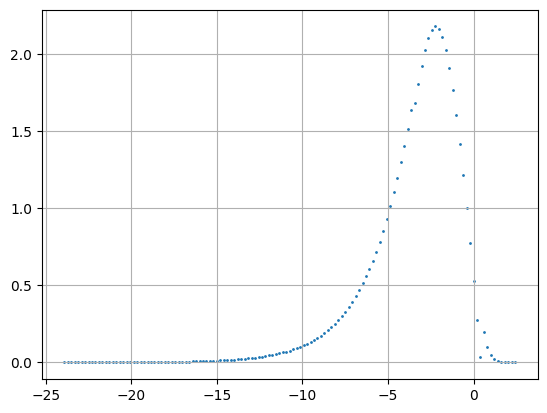

In [ ]:
plt.scatter(xy[:, 1].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [ ]:
xy = torch.arange(-device.total_length_x/2, device.total_length_x/2, step=dx/2, device=memory_type).reshape(-1, 1)
xy = torch.cat((xy, torch.full_like(xy, 0)), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy[:], torch.square(device.refractive_index(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()

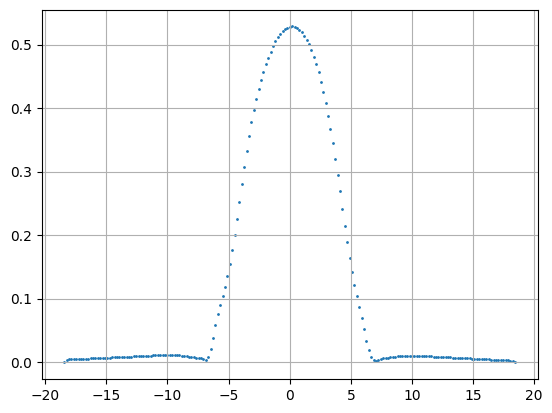

In [ ]:
plt.scatter(xy[:, 0].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()